<a href="https://colab.research.google.com/github/ydg1021/test/blob/main/%EB%93%9C%EB%A1%A0%EC%A2%85%EB%A5%98%EB%B6%84%EB%A5%98_%EA%B0%80%EC%9D%B4%EB%93%9C%EC%BD%94%EB%93%9C_v2_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 드론 종류 분류 프로젝트 (Ground-to-Sky)
## Intel OpenVINO x 금오공과대학교 VisionAI

---

### 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **프로젝트명** | 드론 종류 자동 분류 시스템 (Counter-Drone Intelligence) |
| **핵심 목적** | 지상 탐지 카메라 이미지로 드론 기종 식별 |
| **분류 클래스** | VTOL / QUAD / HEXA - 3종 |
| **핵심 기술** | Ground-to-Sky 필터 → 장면 단위 분할 → MobileNetV2 전이학습 → OpenVINO IR 변환 |
| **성능 기준** | Test Accuracy 80% 이상 (참고 성능: Accuracy 86.8% · Macro-F1 86.6%) |

### 데이터셋 안내

데이터셋(`drone_dataset_30.zip`)은 기종 식별이 가능한 단거리·중거리,
5개 환경(country / sunny / urban / snow / low-light)의 이미지로 구성되어 있습니다.
동영상에서 추출한 연속 프레임이며, 전처리 전 원본 상태이므로
필터링 → 장면 분할 → 학습의 전 과정을 이 노트북이 수행합니다.


## STEP 01 · 환경 설정

In [ ]:
# -- 1-1. 패키지 설치
# (Colab에는 torch/torchvision/scikit-learn 이 사전 설치되어 있음)
#!pip install torch torchvision tqdm scikit-learn matplotlib seaborn -q
!pip install openvino koreanize-matplotlib -q
print("패키지 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 79.3 MB/s eta 0:00:00
패키지 설치 완료


In [ ]:
# -- 1-2. 라이브러리 임포트
import os, re, json, time, random, shutil, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import openvino as ov

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용 장치 : {DEVICE}")
print(f"PyTorch  : {torch.__version__}")
print(f"OpenVINO : {ov.__version__}")

사용 장치 : cuda
PyTorch  : 2.11.0+cu128
OpenVINO : 2026.2.1-21919-ede283a88e3-releases/2026/2


## STEP 02 · 데이터셋 구축

In [ ]:
# -- 2-1. 데이터셋 압축 해제
# [Colab] Drive 의 drone_dataset_30.zip 을 /content 에 풀어서 사용
# [로컬]  BASE 를 zip 을 풀어놓은 폴더로 바꾸면 됨
import zipfile

def extract_zip(src, dst):
    if Path(dst).exists():
        print(f"  이미 존재: {Path(dst).name}"); return
    print(f"  압축 해제: {Path(src).name}")
    Path(dst).mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(src) as z:
        z.extractall(dst)
    print(f"  완료: {Path(dst).name}")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content'
    extract_zip('/content/drive/MyDrive/drone_dataset_30.zip', f'{BASE}/drone_dataset_30')
except ImportError:
    BASE = '.'   # 로컬: 노트북 옆에 drone_dataset_30 폴더
    print(f"로컬 실행: {Path(BASE).resolve()}")

DATA_ROOT = Path(BASE) / 'drone_dataset_30'
WORK      = Path(BASE) / 'drone_clf_work'   # 분할 결과가 만들어질 작업 폴더

DATASETS = {
    'VTOL': DATA_ROOT / 'L1_LC_VTOL',
    'QUAD': DATA_ROOT / 'L3_QUAD_MC',
    'HEXA': DATA_ROOT / 'L1_HEXA_MC',
}
USE_ENVS  = ['country', 'sunny', 'urban', 'snow', 'low-light']
USE_DISTS = ['단거리', '중거리']   # 장거리는 드론이 수 픽셀 수준 → 기종 식별 불가라 미포함

Mounted at /content/drive
  압축 해제: drone_dataset_30.zip
  완료: drone_dataset_30


In [ ]:
# -- 2-2. 데이터셋 구조 파악
def natural_key(p):
    m = re.match(r'^(\d+)_(\d+)$', p.stem)
    if m: return (1, int(m.group(1)), int(m.group(2)))
    m = re.match(r'^(\d+)$', p.stem)
    if m: return (0, 0, int(m.group(1)))
    return (2, 0, 0)

def list_images(folder):
    return sorted([p for p in folder.iterdir()
                   if p.suffix.lower() in ('.jpg', '.jpeg')], key=natural_key)

print(f"{'클래스':<8} {'환경':<14} {'하위폴더':<8} {'이미지수':>8}")
print('=' * 44)
raw_folders = {}   # (cls, env, dist) -> [paths] (시간 순서 유지)
for cls, root in DATASETS.items():
    for env in USE_ENVS:
        for dist in USE_DISTS:
            d = root / env / dist
            if not d.exists(): continue
            imgs = list_images(d)
            if not imgs: continue
            raw_folders[(cls, env, dist)] = imgs
            print(f"{cls:<8} {env:<14} {dist:<8} {len(imgs):>8}")
print('=' * 44)
for cls in DATASETS:
    n = sum(len(v) for (c, _, _), v in raw_folders.items() if c == cls)
    print(f"  {cls} 합계: {n:,}장")
print(f"  전체: {sum(len(v) for v in raw_folders.values()):,}장")

클래스      환경             하위폴더         이미지수
VTOL     country        단거리           205
VTOL     country        중거리           208
VTOL     sunny          단거리           166
VTOL     sunny          중거리           123
VTOL     urban          단거리           200
VTOL     urban          중거리           200
VTOL     snow           단거리           200
VTOL     snow           중거리           200
VTOL     low-light      단거리           165
VTOL     low-light      중거리           177
QUAD     country        단거리           206
QUAD     country        중거리           240
QUAD     sunny          단거리           161
QUAD     sunny          중거리           161
QUAD     urban          단거리           240
QUAD     urban          중거리           200
QUAD     snow           단거리           240
QUAD     snow           중거리           240
QUAD     low-light      단거리           240
QUAD     low-light      중거리           216
HEXA     country        단거리           200
HEXA     country        중거리           161
HEXA     sunny          단거리       

### Ground-to-Sky 필터링

데이터에는 두 종류의 이미지가 섞여 있습니다.

- **Ground-to-Sky**: 지상 카메라가 하늘의 드론을 촬영 → 드론 형태가 보임 (사용)
- **Sky-to-Ground**: 드론이 지표면을 내려다보며 촬영 → 드론이 사진에 없음 (제외)

이미지 상단 40%의 하늘 색상 비율(파란 하늘·흐린 하늘·고밝기)로 판별하며,
하단이 하늘처럼 밝고 균일하면 항공샷으로 보고 제외합니다.
전처리 전 원본 데이터이므로 약 30%가 여기서 필터링됩니다.

In [ ]:
# -- 2-3. Ground-to-Sky 필터링
def is_ground_to_sky(img_path, threshold=0.35):
    try:
        img = Image.open(img_path).convert('RGB').resize((64, 64))
        arr = np.array(img, dtype=np.float32) / 255.0
        top, bot = arr[:26, :, :], arr[45:, :, :]
        r, g, b = top[:,:,0], top[:,:,1], top[:,:,2]
        bright = (r + g + b) / 3.0
        blue_sky   = (b > r + 0.04) & (b > g - 0.01) & (bright > 0.20)
        white_sky  = (bright > 0.65) & (np.abs(r - b) < 0.20) & (np.abs(r - g) < 0.20)
        bright_uni = bright > 0.78
        sky_ratio = float((blue_sky | white_sky | bright_uni).mean())
        r2, g2, b2 = bot[:,:,0], bot[:,:,1], bot[:,:,2]
        bot_sky_ratio = float((((r2 + g2 + b2) / 3.0) > 0.65).mean())
        return sky_ratio > threshold and bot_sky_ratio < 0.40
    except Exception:
        return False

gts_flags = {}
for key, imgs in tqdm(raw_folders.items(), desc='GTS 필터'):
    with ThreadPoolExecutor(max_workers=8) as ex:
        gts_flags[key] = list(ex.map(is_ground_to_sky, imgs))

raw_n = sum(len(v) for v in raw_folders.values())
gts_n = sum(sum(f) for f in gts_flags.values())
print(f"\n필터 결과: {raw_n:,}장 -> {gts_n:,}장 통과 ({gts_n/raw_n*100:.1f}%)")
for cls in DATASETS:
    r = sum(len(v) for (c,_,_), v in raw_folders.items() if c == cls)
    g = sum(sum(f) for (c,_,_), f in gts_flags.items() if c == cls)
    print(f"  {cls}: {r:,} -> {g:,} ({g/r*100:.1f}%)")

GTS 필터:   0%|          | 0/30 [00:00<?, ?it/s]


필터 결과: 5,909장 -> 4,280장 통과 (72.4%)
  VTOL: 1,844 -> 1,422 (77.1%)
  QUAD: 2,144 -> 1,424 (66.4%)
  HEXA: 1,921 -> 1,434 (74.6%)


### 장면 경계 검출 (Scene Segmentation)

데이터가 동영상의 연속 프레임이므로, 인접 프레임은 사실상 같은 사진입니다.
이미지 단위 무작위 분할은 거의 같은 사진이 train/test에 동시에 들어가
성능이 부풀려지므로, **연속 프레임 묶음 단위**로 분할해야 합니다.
연속 프레임 간 이미지 차이가 큰 지점을 장면 전환으로 판단해 프레임마다
장면 ID를 부여하고, 분할 묶음이 장면 경계를 넘지 않도록 합니다.

In [ ]:
# -- 2-4. 장면 경계 검출
def scene_boundaries(imgs, thr=0.12, max_len=60, min_len=8):
    """연속 프레임 간 평균 픽셀 차이가 thr 초과이면 장면 전환으로 판단.
    min_len 미만의 짧은 장면은 이전 장면에 병합 (흔들림·노이즈 과분할 방지)"""
    def load(p):
        return np.asarray(Image.open(p).convert('L').resize((64, 64)),
                          dtype=np.float32) / 255.0
    with ThreadPoolExecutor(max_workers=8) as ex:
        arrs = list(ex.map(load, imgs))
    groups, run = [[0]], 1
    for i in range(1, len(imgs)):
        diff = float(np.abs(arrs[i] - arrs[i-1]).mean())
        if diff > thr or run >= max_len:   # 장면 전환 또는 과대 장면 방지
            groups.append([]); run = 0
        groups[-1].append(i); run += 1
    merged = []
    for g in groups:
        if merged and len(g) < min_len: merged[-1].extend(g)
        else: merged.append(g)
    scene_ids = [0] * len(imgs)
    for k, g in enumerate(merged):
        for i in g: scene_ids[i] = k
    return scene_ids

gts_folders = {}   # (cls, env, dist) -> [(장면ID, 경로)]  * 필터 통과분만
for key, imgs in tqdm(raw_folders.items(), desc='장면 검출'):
    sids = scene_boundaries(imgs)          # 장면 검출은 원본 시퀀스 기준
    kept = [(s, p) for s, p, f in zip(sids, imgs, gts_flags[key]) if f]
    if kept: gts_folders[key] = kept

for cls in DATASETS:
    n_scene = sum(len({s for s, _ in v}) for (c,_,_), v in gts_folders.items() if c == cls)
    n_img   = sum(len(v) for (c,_,_), v in gts_folders.items() if c == cls)
    print(f"  {cls}: {n_img:,}장 / {n_scene}개 장면 (장면당 평균 {n_img/n_scene:.0f}장)")

장면 검출:   0%|          | 0/30 [00:00<?, ?it/s]

  VTOL: 1,422장 / 42개 장면 (장면당 평균 34장)
  QUAD: 1,424장 / 44개 장면 (장면당 평균 32장)
  HEXA: 1,434장 / 32개 장면 (장면당 평균 45장)


In [ ]:
# -- 2-5. 클래스 균형: 최소 클래스 기준 개수 통일
# 필터 통과량이 클래스마다 조금씩 다르므로 최소 클래스에 맞춰 균형을 보장
class_totals = {c: sum(len(v) for (c2, _, _), v in gts_folders.items() if c2 == c)
                for c in DATASETS}
min_cnt = min(class_totals.values())
print(f"필터 후: {class_totals} -> 클래스당 {min_cnt:,}장으로 통일")
for (cls, env, dist), kept in list(gts_folders.items()):
    frac = min_cnt / class_totals[cls]
    n_keep = round(len(kept) * frac)
    if n_keep < len(kept):     # 환경 비율을 유지하며 폴더별 비례 축소 (순서 유지)
        rng = random.Random(f'{SEED}/trim/{cls}/{env}/{dist}')
        idx = sorted(rng.sample(range(len(kept)), n_keep))
        gts_folders[(cls, env, dist)] = [kept[i] for i in idx]

필터 후: {'VTOL': 1422, 'QUAD': 1424, 'HEXA': 1434} -> 클래스당 1,422장으로 통일


In [ ]:
# -- 2-6. 장면 기반 묶음 단위 train/val/test 분할 + 병합 복사
CHUNK = 40                          # 장면 내부에서 연속 40프레임을 한 묶음으로
SPLIT_RATIO = (0.70, 0.15, 0.15)   # train / val / test

if WORK.exists(): shutil.rmtree(WORK)   # 재실행해도 안전

split_counts = {s: {c: 0 for c in DATASETS} for s in ('train', 'val', 'test')}
for cls in DATASETS:
    scenes = {}                     # (env, dist, 장면ID) -> [경로]
    for (c2, env, dist), kept in gts_folders.items():
        if c2 != cls: continue
        for sid, p in kept:
            scenes.setdefault((env, dist, sid), []).append(p)
    pool = []                       # 묶음은 장면 경계를 넘지 않음
    for (env, dist, sid), paths in scenes.items():
        for i in range(0, len(paths), CHUNK):
            pool.append(((env, dist, sid), paths[i:i+CHUNK]))
    rng = random.Random(f'{SEED}/assign/{cls}')
    rng.shuffle(pool)
    total = sum(len(v) for _, v in pool)
    cum = 0
    cut_te, cut_va = total * SPLIT_RATIO[2], total * (SPLIT_RATIO[2] + SPLIT_RATIO[1])
    for (env, dist, sid), paths in pool:   # 묶음은 통째로 한 분할에만 들어감
        split = 'test' if cum < cut_te else ('val' if cum < cut_va else 'train')
        cum += len(paths)
        # 원본과 같은 환경/거리 폴더 구조 유지 (ImageFolder는 클래스 폴더 아래를 재귀 탐색)
        dst_dir = WORK / split / cls / env / dist
        dst_dir.mkdir(parents=True, exist_ok=True)
        for p in paths:
            shutil.copy2(p, dst_dir / p.name)
        split_counts[split][cls] += len(paths)

print(f"{'분할':<8} {'HEXA':>6} {'QUAD':>6} {'VTOL':>6} {'합계':>7}")
for split, cc in split_counts.items():
    print(f"{split:<8} {cc['HEXA']:>6} {cc['QUAD']:>6} {cc['VTOL']:>6} {sum(cc.values()):>7}")

분할         HEXA   QUAD   VTOL      합계
train       984    977    994    2955
val         214    221    206     641
test        224    226    222     672


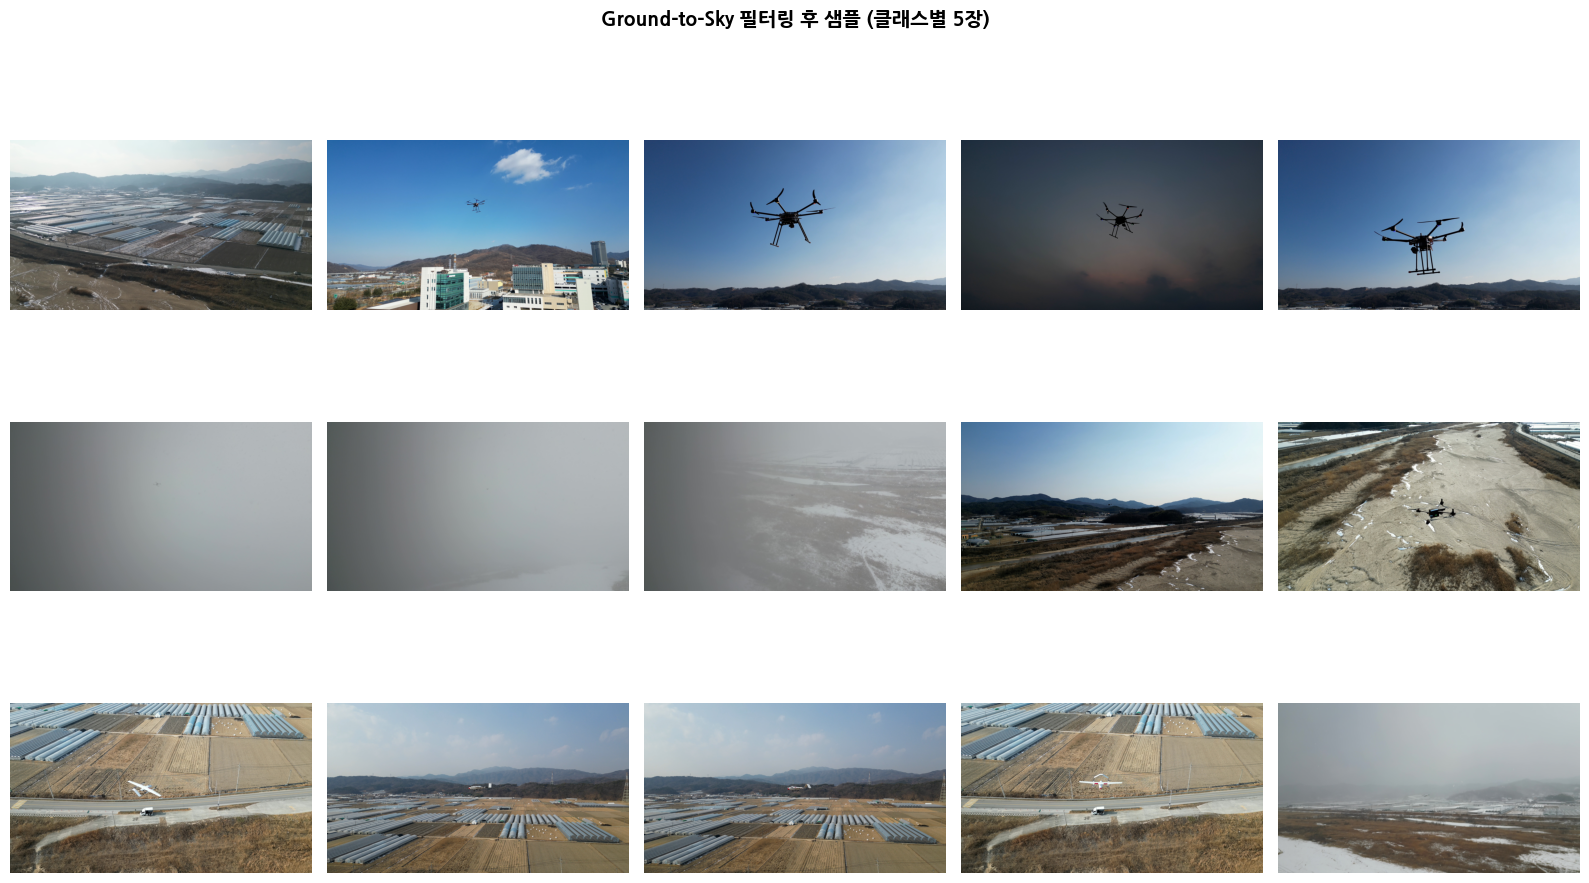

저장: /content/sample_gts.png


In [ ]:
# -- 2-7. 샘플 이미지 시각화
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Ground-to-Sky 필터링 후 샘플 (클래스별 5장)', fontsize=14, fontweight='bold')
for row, cls in enumerate(['HEXA', 'QUAD', 'VTOL']):
    imgs = [p for p in (WORK / 'train' / cls).rglob('*') if p.suffix.lower() in ('.jpg', '.jpeg')]
    random.shuffle(imgs)
    for col in range(5):
        ax = axes[row][col]
        ax.imshow(Image.open(imgs[col]).convert('RGB'))
        if col == 0: ax.set_ylabel(cls, fontsize=12, fontweight='bold')
        ax.axis('off')
plt.tight_layout()
plt.savefig(f'{BASE}/sample_gts.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"저장: {BASE}/sample_gts.png")

In [ ]:
# -- 2-8. DataLoader 준비
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 if os.name != 'nt' else 0   # Windows는 노트북에서 워커 프로세스가 불안정

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(WORK / 'train', transform=train_tf)
val_ds   = ImageFolder(WORK / 'val',   transform=eval_tf)
test_ds  = ImageFolder(WORK / 'test',  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds.classes
print(f"클래스 순서 : {CLASS_NAMES}")
print(f"Train {len(train_ds):,} / Val {len(val_ds):,} / Test {len(test_ds):,}")

클래스 순서 : ['HEXA', 'QUAD', 'VTOL']
Train 2,955 / Val 641 / Test 672


## STEP 03 · 모델 학습 (MobileNetV2 2단계 전이학습)

In [ ]:
# -- 3-1. 모델 설정
NUM_CLASSES   = 3
PHASE1_EPOCHS, PHASE2_EPOCHS = 10, 20
PHASE1_LR, PHASE2_LR = 1e-3, 1e-4
PATIENCE = 5

model = models.mobilenet_v2(weights='IMAGENET1K_V1')
for p in model.features.parameters():
    p.requires_grad = False
model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.last_channel, NUM_CLASSES))
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 {total:,} | 학습 가능 {trainable:,} ({trainable/total*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 153MB/s]


총 파라미터 2,227,715 | 학습 가능 3,843 (0.2%)


In [ ]:
# -- 3-2. 학습 / 검증 함수
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx  = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Val  '
    pbar = tqdm(loader, desc=f'  [{desc}]', ncols=90, leave=False)
    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            preds       = out.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()
            n          += imgs.size(0)
            pbar.set_postfix({'loss': f'{total_loss/n:.4f}', 'acc': f'{correct/n:.4f}'})
    return total_loss / n, correct / n

def train_phase(model, tr_ld, val_ld, optimizer, criterion,
                epochs, device, name, scheduler=None, patience=5):
    history = {'tr_loss':[], 'val_loss':[], 'tr_acc':[], 'val_acc':[]}
    best_acc, best_wts, no_improve = 0.0, None, 0
    print(f'\n{"="*60}\n  {name}  (최대 {epochs} 에포크 | patience={patience})\n{"="*60}')
    print(f'  {"Epoch":>5} | {"TrLoss":>7} {"ValLoss":>7} | {"TrAcc":>7} {"ValAcc":>7}')
    print(f'  {"-"*50}')
    for ep in range(1, epochs + 1):
        tr_loss,  tr_acc  = run_epoch(model, tr_ld,  optimizer, criterion, device, True)
        val_loss, val_acc = run_epoch(model, val_ld, optimizer, criterion, device, False)
        if scheduler: scheduler.step()
        for k, v in [('tr_loss',tr_loss),('val_loss',val_loss),('tr_acc',tr_acc),('val_acc',val_acc)]:
            history[k].append(v)
        flag = ''
        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0; flag = '  *'
        else:
            no_improve += 1
        print(f'  {ep:>5} | {tr_loss:>7.4f} {val_loss:>7.4f} | {tr_acc:>7.4f} {val_acc:>7.4f}{flag}')
        if no_improve >= patience:
            print(f'  -> Early stopping  (best val_acc: {best_acc:.4f})'); break
    model.load_state_dict({k: v.to(device) for k, v in best_wts.items()})
    print(f'  완료  최고 Val Acc: {best_acc:.4f}')
    return history, best_acc

In [ ]:
# -- 3-3. Phase 1: 분류기만 학습 (Frozen Base)
criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)

hist1, best1 = train_phase(
    model, train_loader, val_loader, optimizer1, criterion,
    PHASE1_EPOCHS, DEVICE, 'Phase 1 - Frozen Base (분류기만 학습)', patience=PATIENCE
)


  Phase 1 - Frozen Base (분류기만 학습)  (최대 10 에포크 | patience=5)
  Epoch |  TrLoss ValLoss |   TrAcc  ValAcc
  --------------------------------------------------


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

      1 |  0.8047  0.9130 |  0.6460  0.6178  *


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

...

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

      7 |  0.4325  0.7291 |  0.8338  0.6927


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

      8 |  0.4156  0.7460 |  0.8311  0.6677
  -> Early stopping  (best val_acc: 0.7114)
  완료  최고 Val Acc: 0.7114


In [ ]:
# -- 3-4. Phase 2: Fine-tuning (마지막 5개 블록)
NUM_UNFREEZE = 5
for param in model.features.parameters():
    param.requires_grad = False
blocks = list(model.features.children())
for i, block in enumerate(blocks):
    if i >= len(blocks) - NUM_UNFREEZE:
        for param in block.parameters():
            param.requires_grad = True

trainable2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 학습 파라미터: {trainable2:,}")

optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE2_LR)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS)

hist2, best_val = train_phase(
    model, train_loader, val_loader, optimizer2, criterion,
    PHASE2_EPOCHS, DEVICE, 'Phase 2 - Fine-tuning (마지막 5블록)',
    scheduler=scheduler2, patience=PATIENCE
)

Phase 2 학습 파라미터: 1,685,187

  Phase 2 - Fine-tuning (마지막 5블록)  (최대 20 에포크 | patience=5)
  Epoch |  TrLoss ValLoss |   TrAcc  ValAcc
  --------------------------------------------------


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

      1 |  0.2367  0.4323 |  0.9164  0.8393  *


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

...

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

      9 |  0.0078  0.5009 |  0.9980  0.8253


  [Train]:   0%|                                                   | 0/93 [00:00<?, ?it/s]

  [Val  ]:   0%|                                                   | 0/21 [00:00<?, ?it/s]

     10 |  0.0109  0.4593 |  0.9970  0.7941
  -> Early stopping  (best val_acc: 0.9189)
  완료  최고 Val Acc: 0.9189


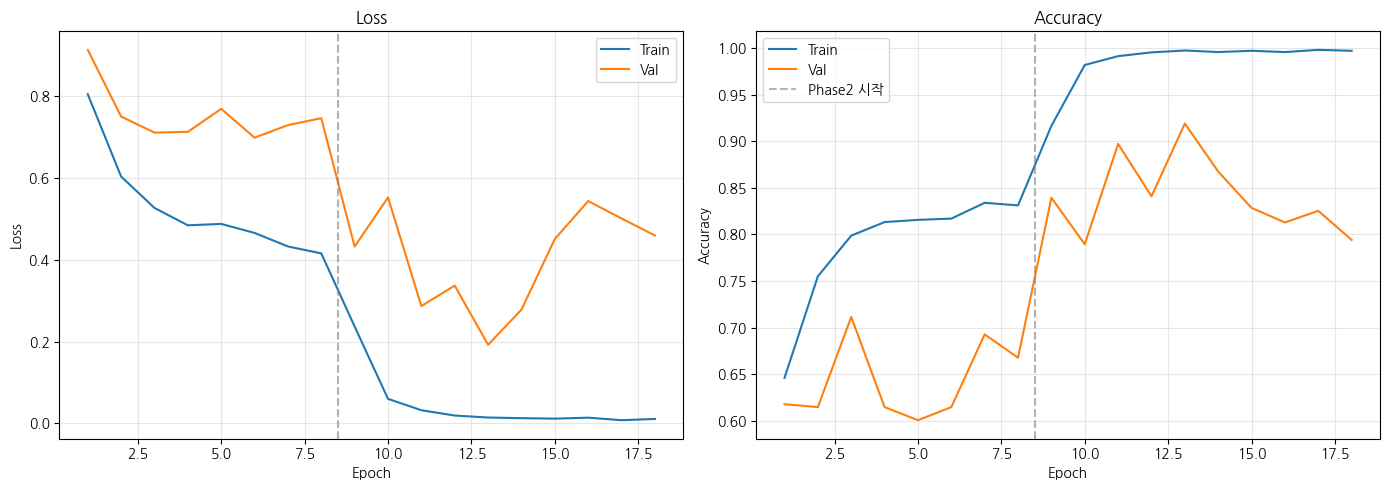

저장: /content/learning_curves.png


In [ ]:
# -- 3-5. 학습 곡선
hist = {k: hist1[k] + hist2[k] for k in hist1}
ep = range(1, len(hist['tr_loss']) + 1)
p1 = len(hist1['tr_loss'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, hist['tr_loss'], label='Train'); ax1.plot(ep, hist['val_loss'], label='Val')
ax1.axvline(p1 + 0.5, color='gray', ls='--', alpha=0.6)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, hist['tr_acc'], label='Train'); ax2.plot(ep, hist['val_acc'], label='Val')
ax2.axvline(p1 + 0.5, color='gray', ls='--', alpha=0.6, label='Phase2 시작')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"저장: {BASE}/learning_curves.png")

## STEP 04 · 성능 평가

테스트 세트는 학습에 사용되지 않은 **별도 장면**으로만 구성되어 있으므로,
아래 수치는 새로운 장면에 대한 일반화 성능입니다.

In [ ]:
# -- 4-1. 테스트 평가
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='테스트'):
        all_preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro')
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Macro-F1 : {test_f1:.4f} ({test_f1*100:.1f}%)")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

테스트:   0%|          | 0/21 [00:00<?, ?it/s]

Accuracy : 0.8333 (83.3%)
Macro-F1 : 0.8292 (82.9%)
              precision    recall  f1-score   support

        HEXA       0.85      0.96      0.90       224
        QUAD       0.85      0.86      0.85       226
        VTOL       0.79      0.68      0.73       222

    accuracy                           0.83       672
   macro avg       0.83      0.83      0.83       672
weighted avg       0.83      0.83      0.83       672



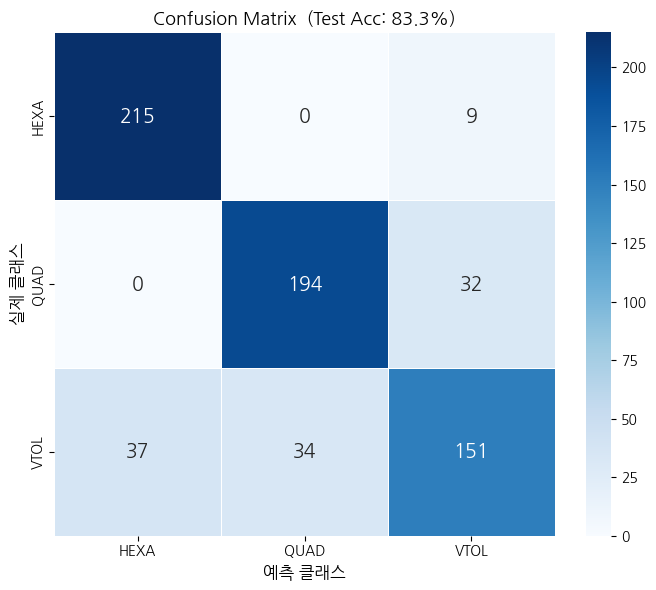

저장: /content/confusion_matrix.png


In [ ]:
# -- 4-2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('예측 클래스', fontsize=12); ax.set_ylabel('실제 클래스', fontsize=12)
ax.set_title(f'Confusion Matrix  (Test Acc: {test_acc:.1%})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"저장: {BASE}/confusion_matrix.png")

In [ ]:
# -- 4-3. 환경별 오류 분석 (폴더 구조에 출처가 보존되어 있음)
from collections import Counter
stats, errors = Counter(), Counter()
for (path, label), pred in zip(test_ds.samples, all_preds):
    parts = Path(path).parts   # .../test/<클래스>/<환경>/<거리>/<파일>
    cls, env = parts[-4], parts[-3]
    stats[(cls, env)] += 1
    if pred != label:
        errors[(cls, env, CLASS_NAMES[pred])] += 1

print(f"{'클래스':<6} {'환경':<12} {'전체':>5} {'오류':>5}  상세")
for (cls, env), n in sorted(stats.items()):
    errs = {p: c for (c2, e2, p), c in errors.items() if (c2, e2) == (cls, env)}
    detail = ', '.join(f'->{p}:{c}' for p, c in sorted(errs.items(), key=lambda x: -x[1]))
    print(f"{cls:<6} {env:<12} {n:>5} {sum(errs.values()):>5}  {detail}")

클래스    환경              전체    오류  상세
HEXA   country         40     0  
HEXA   snow            43     1  ->VTOL:1
HEXA   sunny           61     4  ->VTOL:4
HEXA   urban           80     4  ->VTOL:4
QUAD   country         40    22  ->VTOL:22
QUAD   snow            37     3  ->VTOL:3
QUAD   sunny           69     7  ->VTOL:7
QUAD   urban           80     0  
VTOL   country        118    35  ->QUAD:34, ->HEXA:1
VTOL   low-light       40     0  
VTOL   snow            28     0  
VTOL   urban           36    36  ->HEXA:36


## STEP 05 · OpenVINO 최적화

학습한 모델을 OpenVINO IR로 변환하고, PyTorch와 **동일 조건에서** 추론 성능을
비교합니다 — 1장씩(실서비스 조건)과 배치 32(처리량 조건)를 각각 측정합니다.

In [ ]:
# -- 5-1. 모델 저장 및 OpenVINO IR 변환 (PyTorch 직접 변환)
# ONNX 경유 없이 ov.convert_model() 로 직접 변환

THRESHOLD   = 0.80
MODEL_DIR   = f'{BASE}/drone_clf_model'
PT_PATH     = f'{MODEL_DIR}/mobilenetv2_drone.pt'
OV_XML      = f'{MODEL_DIR}/mobilenetv2_drone_ir.xml'
OPENVINO_OK = False

os.makedirs(MODEL_DIR, exist_ok=True)

if test_acc >= THRESHOLD:
    torch.save(model.state_dict(), PT_PATH)
    pt_mb = os.path.getsize(PT_PATH) / 1e6
    print(f"PyTorch 저장: {PT_PATH}  ({pt_mb:.1f} MB)")

    # OpenVINO 직접 변환
    model.eval().cpu()
    dummy    = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    core     = ov.Core()
    ov_model = ov.convert_model(model, example_input=dummy)
    ov.save_model(ov_model, OV_XML)

    xml_mb = os.path.getsize(OV_XML) / 1e6
    bin_mb = os.path.getsize(OV_XML.replace('.xml', '.bin')) / 1e6
    print(f"OpenVINO IR : {OV_XML}")
    print(f"  .xml: {xml_mb:.2f} MB  |  .bin: {bin_mb:.2f} MB  |  합계: {xml_mb+bin_mb:.2f} MB")
    OPENVINO_OK = True
else:
    print(f"Accuracy {test_acc:.1%} < {THRESHOLD:.0%} -> 모델 저장 건너뜀")

PyTorch 저장: /content/drone_clf_model/mobilenetv2_drone.pt  (9.2 MB)
OpenVINO IR : /content/drone_clf_model/mobilenetv2_drone_ir.xml
  .xml: 0.20 MB  |  .bin: 4.42 MB  |  합계: 4.62 MB


In [ ]:
# -- 5-2. Google Drive에 모델 저장 (Colab 실행 시)
if OPENVINO_OK:
    try:
        from google.colab import drive as _drive
        DRIVE_MODEL = Path('/content/drive/MyDrive/drone_clf_model')
        DRIVE_MODEL.mkdir(parents=True, exist_ok=True)
        for src in [PT_PATH, OV_XML, OV_XML.replace('.xml', '.bin')]:
            if Path(src).exists():
                shutil.copy(src, DRIVE_MODEL)
                print(f"Drive 저장: {Path(src).name}")
    except ImportError:
        print("로컬 실행 - Drive 저장 생략")

Drive 저장: mobilenetv2_drone.pt
Drive 저장: mobilenetv2_drone_ir.xml
Drive 저장: mobilenetv2_drone_ir.bin


In [ ]:
# -- 5-3. Base Model vs OpenVINO IR 추론 성능 비교 (동일 조건: 둘 다 1장씩)
if OPENVINO_OK:
    compiled  = core.compile_model(OV_XML, 'CPU')
    out_layer = compiled.output(0)

    N = 100
    bench_loader = DataLoader(test_ds, batch_size=N, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED))
    imgs, labels = next(iter(bench_loader))
    imgs_np = imgs.numpy()
    labels  = labels.numpy()

    # Base Model (PyTorch CPU) - 1장씩
    with torch.no_grad():
        _ = model(imgs[:1])   # warmup
        t0 = time.perf_counter()
        base_preds = [model(imgs[i:i+1]).argmax(1).item() for i in range(len(imgs))]
        base_ms = (time.perf_counter() - t0) / len(imgs) * 1000
    base_acc = accuracy_score(labels, base_preds)
    base_mb  = os.path.getsize(PT_PATH) / 1e6

    # OpenVINO IR (CPU) - 1장씩
    _ = compiled([imgs_np[:1]])   # warmup
    t0 = time.perf_counter()
    ov_preds = [int(np.argmax(compiled([imgs_np[i:i+1]])[out_layer][0])) for i in range(len(imgs_np))]
    ov_ms  = (time.perf_counter() - t0) / len(imgs_np) * 1000
    ov_acc = accuracy_score(labels, ov_preds)
    ov_mb  = (os.path.getsize(OV_XML) + os.path.getsize(OV_XML.replace('.xml','.bin'))) / 1e6

    print(f"\n{'='*56}")
    print(f"  {'항목':<22} {'Base Model':>14} {'OpenVINO IR':>14}")
    print(f"{'='*56}")
    print(f"  {'모델 크기 (MB)':<22} {base_mb:>14.1f} {ov_mb:>14.1f}")
    print(f"  {'추론 시간 (ms/장)':<22} {base_ms:>14.2f} {ov_ms:>14.2f}")
    print(f"  {'FPS':<22} {1000/base_ms:>14.1f} {1000/ov_ms:>14.1f}")
    print(f"  {'Accuracy':<22} {base_acc:>14.4f} {ov_acc:>14.4f}")
    print(f"{'='*56}")
    print(f"\n  추론 속도: {base_ms/ov_ms:.2f}x 향상")
    print(f"  모델 크기: {base_mb/ov_mb:.2f}x 감소")


  항목                         Base Model    OpenVINO IR
  모델 크기 (MB)                        9.2            4.6
  추론 시간 (ms/장)                    31.88          11.84
  FPS                              31.4           84.5
  Accuracy                       0.8700         0.8700

  추론 속도: 2.69x 향상
  모델 크기: 1.98x 감소


## STEP 06 · 웹 UI (Streamlit)

In [ ]:
# -- 6-1. Streamlit 앱 생성
app_code = '''import streamlit as st
import numpy as np
from PIL import Image
import openvino as ov
import time

OV_XML      = "drone_clf_model/mobilenetv2_drone_ir.xml"
CLASS_NAMES = ["HEXA", "QUAD", "VTOL"]
IMG_SIZE    = 224
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])
CLASS_INFO = {"VTOL": "고정익+로터 하이브리드 (흰색, 날개 있음)",
              "QUAD": "쿼드콥터 (검정, 4개 로터)",
              "HEXA": "헥사콥터 (회색, 6개 로터)"}

@st.cache_resource
def load_model():
    return ov.Core().compile_model(OV_XML, "CPU")

def preprocess(img):
    img = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    x = (np.array(img, dtype=np.float32) / 255.0 - MEAN) / STD
    return x.transpose(2, 0, 1)[np.newaxis].astype(np.float32)

def softmax(x):
    e = np.exp(x - x.max()); return e / e.sum()

st.set_page_config(page_title="드론 종류 분류기", page_icon="🚁", layout="wide")
st.title("🚁 대드론 탐지 - 드론 종류 분류기")
st.markdown("**지상 탐지 카메라로 촬영한 드론 이미지**를 업로드하면 기종을 분류합니다.")
st.caption("Intel OpenVINO CPU 추론 | Ground-to-Sky 전용 모델")
st.divider()
col_up, col_res = st.columns([1, 1])
with col_up:
    uploaded = st.file_uploader("드론 이미지 업로드", type=["jpg", "jpeg", "png"])
if uploaded:
    pil_img = Image.open(uploaded)
    col_up.image(pil_img, caption="입력 이미지", use_container_width=True)
    with st.spinner("추론 중..."):
        compiled  = load_model()
        out_layer = compiled.output(0)
        t0 = time.perf_counter()
        logits = compiled([preprocess(pil_img)])[out_layer][0]
        ms = (time.perf_counter() - t0) * 1000
    probs = softmax(logits)
    top_i = int(np.argmax(probs))
    top_c = CLASS_NAMES[top_i]
    with col_res:
        st.markdown("### 분류 결과")
        st.success(f"**{top_c}** - {CLASS_INFO[top_c]}")
        st.metric("신뢰도", f"{probs[top_i]*100:.1f}%")
        st.metric("추론 시간", f"{ms:.1f} ms")
        st.divider()
        st.markdown("#### 클래스별 확률")
        for cls, prob in zip(CLASS_NAMES, probs):
            st.progress(float(prob), text=f"{cls}: {prob*100:.1f}%")
'''

with open(f'{BASE}/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print(f'app.py 저장: {BASE}/app.py')
print()
print('Streamlit 실행 (Colab):')
print('  !pip install pyngrok -q')
print('  from pyngrok import ngrok')
print('  ngrok.set_auth_token("YOUR_TOKEN")')
print('  import subprocess; subprocess.Popen(["streamlit","run",f"{BASE}/app.py"])')
print('  import time; time.sleep(3)')
print('  print(ngrok.connect(8501).public_url)')
print()
print('Streamlit 실행 (로컬): streamlit run app.py')

app.py 저장: /content/app.py

Streamlit 실행 (Colab):
  !pip install pyngrok -q
  from pyngrok import ngrok
  ngrok.set_auth_token("YOUR_TOKEN")
  import subprocess; subprocess.Popen(["streamlit","run",f"{BASE}/app.py"])
  import time; time.sleep(3)
  print(ngrok.connect(8501).public_url)

Streamlit 실행 (로컬): streamlit run app.py


## 마무리 · 성능 요약과 활용 시 유의사항

### 참고 성능 (RTX 4080, 배포 데이터셋 전체 기준)

| 지표 | 값 |
|---|---|
| Test Accuracy | **86.8%** |
| Macro-F1 | **86.6%** |
| 클래스별 recall | HEXA 99% / QUAD 91% / VTOL 70% |
| OpenVINO 1장 추론 | 2.9ms (PyTorch 대비 3.3배, 크기 2.0배 감소) |

- 데이터: 5,909장 → GTS 필터 통과 4,280장(72%) → train 2,955 / val 641 / test 672

### 활용 시 유의사항

1. **VTOL→HEXA 오인**: 날개 실루엣이 잘 보이지 않는 앵글·거리의 특정 장면에서
   VTOL을 HEXA로 오인하는 경우가 남은 오류의 대부분입니다.
2. **장면 다양성**: 환경당 촬영 클립 수가 제한적이라, 전혀 새로운 장소·기체
   도색에 대한 일반화는 보장 범위 밖입니다. 실전 투입 전 현장 데이터로
   추가 검증을 권장합니다.
3. **GTS 필터 임계값**: 하드코딩된 휴리스틱이라 새로운 촬영 조건에서는
   통과율을 먼저 확인하는 것을 권장합니다.